In [11]:
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx, serialization
import optax

import matplotlib.pyplot as plt
from typing import Callable

jax.devices()

[CudaDevice(id=0)]

In [98]:
class SpectralConv2D(nnx.Module):
    def __init__(self, in_channels, out_channels, modes, rngs):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        init_w_scale = 1 / (in_channels * out_channels)
        init_w_kwargs = {
            'shape': (2 * modes + 1, modes + 1, in_channels, out_channels),
            'minval': -init_w_scale, 'maxval': init_w_scale
        }
        self.w_re = nnx.Param(jax.random.uniform(rngs(), **init_w_kwargs))
        self.w_im = nnx.Param(jax.random.uniform(rngs(), **init_w_kwargs))

    def __call__(self, x):
        n_px = x.shape[-2]
        mode_start, mode_end = n_px // 2 - self.modes, n_px // 2 + self.modes + 1

        x_fft = jnp.fft.rfft2(x, axes=(-3, -2))
        x_fft_shifted = jnp.fft.fftshift(x_fft, axes=-3)
        x_fft_sliced = x_fft_shifted[..., mode_start:mode_end, :self.modes + 1, :]

        w = self.w_re + 1j * self.w_im
        y_fft_sliced = jnp.einsum('bnmi, nmio -> bnmo', x_fft_sliced, w)

        y_fft_shifted = jnp.zeros(x_fft.shape[:-1] + (self.out_channels,), dtype=complex)
        y_fft_shifted = y_fft_shifted.at[..., mode_start:mode_end, :self.modes + 1, :].set(y_fft_sliced)
        y_fft = jnp.fft.ifftshift(y_fft_shifted, axes=-3)
        y = jnp.fft.irfft2(y_fft, axes=(-3, -2))

        return y


class FNOLayer(nnx.Module):
    def __init__(self, in_channels, out_channels, modes, activation, rngs):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.activation = activation

        self.spectral_conv = SpectralConv2D(in_channels, out_channels, modes, rngs=rngs)
        self.bypass_conv = nnx.Conv(in_channels, out_channels, kernel_size=1, rngs=rngs)

    def __call__(self, x):
        return self.activation(
            self.spectral_conv(x)
            + self.bypass_conv(x)
        )


class ScatteringFNO(nnx.Module):
    def __init__(self, dout, hidden_dims, modes, activation, rngs):
        self.din = 1
        self.dout = dout
        self.lifting = nnx.Conv(self.din, hidden_dims[0], kernel_size=1, rngs=rngs)
        self.fourier_layers = nnx.List([
            FNOLayer(hidden_dims[i], hidden_dims[i + 1], modes, activation, rngs)
            for i in range(len(hidden_dims) - 1)
        ])
        self.projection = nnx.Conv(hidden_dims[-1], 2 * self.dout, kernel_size=1, rngs=rngs)

    def __call__(self, x):
        x = self.lifting(x[..., None])
        for layer in self.fourier_layers:
            x = layer(x)
        x = self.projection(x)
        x = x[..., :self.dout] + 1j * x[..., self.dout:]
        return x

In [99]:
propagating_indices = np.array([
    [0, -1,  0,  0,  1, -1, -1,  1,  1, -2,  0,  0,  2, -2, -2, -1, -1,  1,  1,  2,  2, -2, -2,  2,  2, -3,  0,  0,  3, -3, -3, -1, -1,  1,  1,  3,  3, -3, -3, -2, -2,  2,  2,  3,  3, -4,  0,  0, 4, -4, -4, -1, -1,  1,  1,  4,  4, -3, -3,  3,  3],
    [0,  0, -1,  1,  0, -1,  1, -1,  1,  0, -2,  2,  0, -1,  1, -2,  2, -2,  2, -1,  1, -2,  2, -2,  2,  0, -3,  3,  0, -1,  1, -3,  3, -3,  3, -1,  1, -2,  2, -3,  3, -3,  3, -2,  2,  0, -4,  4, 0, -1,  1, -4,  4, -4,  4, -1,  1, -3,  3, -3,  3]
])

def extract_amps_from_fields(fields, n_modes):
    B, H, W, C = fields.shape
    all_modes = jnp.fft.fft2(fields, axes=(-3, -2)) / (H * W)
    return all_modes[..., propagating_indices[0, :n_modes], propagating_indices[1, :n_modes], :]

In [100]:
class NormalizedScatteringFNO(nnx.Module):
    def __init__(self, scattering_fno, n_propagating_modes, relative_period):
        self.scattering_fno = scattering_fno
        self.n_propagating_modes = n_propagating_modes
        p = relative_period
        mode_n, mode_m = propagating_indices[:, :n_propagating_modes]
        kx = mode_n / p
        ky = mode_m / p
        self.kz = np.sqrt(1 - kx ** 2 - ky ** 2)

    def __call__(self, x):
        field_maps = self.scattering_fno(x)
        amps = extract_amps_from_fields(field_maps, self.n_propagating_modes)
        total_amps_norm = jnp.sum(jnp.abs(amps) ** 2, axis=-1)
        total_energy = jnp.sum(total_amps_norm * self.kz[None, :], axis=-1)
        return amps / jnp.sqrt(total_energy)[:, None, None]

In [116]:
color_i = 2
color = ['red', 'green', 'blue'][color_i]
wavelength = [650, 550, 450][color_i]
n_propagating = [29, 45, 61][color_i]
print(color, wavelength, n_propagating)

x_data = np.load('freeform_training_patterns_32bit.npy')
x_permutation = jax.random.permutation(jax.random.key(0), x_data.shape[0])
x_data = x_data[x_permutation]

full_amp_data = np.load(f'{color}_freeform_accurate.npy')[:, ::2, :2, :n_propagating]

print(x_data.shape, full_amp_data.shape)

y_data = full_amp_data.reshape(-1, 4, n_propagating).transpose(0, 2, 1)  # tx, ty, rx, ry

x_data = jax.image.resize(x_data, (x_data.shape[0], 64, 64), method='bilinear')

data_variance = np.mean(np.var(y_data.reshape(y_data.shape[0], -1), axis=-1))
print('Dataset variance:', data_variance)
# y_data /= np.sqrt(data_variance)

print(x_data.shape, x_data.dtype)
print(y_data.shape, y_data.dtype)

blue 450 61
(33792, 100, 100) (33792, 2, 2, 61)
Dataset variance: 0.004416428
(33792, 64, 64) float32
(33792, 61, 4) complex64


In [117]:
# Normalize training data by energy (as there is small error)
p = 2000 / wavelength
kx, ky = propagating_indices[:, :n_propagating] / p
kz = np.sqrt(1 - kx ** 2 - ky ** 2)

tx, ty, rx, ry = np.unstack(y_data, axis=-1)
tz = (tx * kx + ty * ky) / kz
rz = (rx * kx + ry * ky) / kz
modewise_norms = np.abs(tx) ** 2 + np.abs(ty) ** 2 + np.abs(tz) ** 2 + np.abs(rx) ** 2 + np.abs(ry) ** 2 + np.abs(rz) ** 2
total_powers = np.sum(modewise_norms * kz, axis=-1)
print(total_powers)
print(np.max(np.abs(total_powers - 1)))
print(np.sum((np.abs(total_powers - 1)) > 0.1))

good_sample_i = np.where((np.abs(total_powers - 1)) < 0.1)
x_data = x_data[good_sample_i]
y_data = (y_data / np.sqrt(total_powers)[:, None, None])[good_sample_i]

tx, ty, rx, ry = np.unstack(y_data, axis=-1)
tz = (tx * kx + ty * ky) / kz
rz = (rx * kx + ry * ky) / kz
modewise_norms = np.abs(tx) ** 2 + np.abs(ty) ** 2 + np.abs(tz) ** 2 + np.abs(rx) ** 2 + np.abs(ry) ** 2 + np.abs(rz) ** 2
total_powers = np.sum(modewise_norms * kz, axis=-1)
print(np.max(np.abs(total_powers - 1)))

[1.00000008 0.99999878 0.99999236 ... 0.99999765 1.00001304 1.00000393]
189.6411694670946
69
1.837541333538084e-07


In [118]:
# check what portion of energy is in tx
x_power = np.sum((np.abs(tx) ** 2) * kz, axis=-1)
x_power

array([0.02556558, 0.01665239, 0.06144611, ..., 0.05714077, 0.04972612,
       0.04752089], shape=(33723,))

In [119]:
n_train = 2 ** 15
n_val = 128

x_train = x_data[:n_train]
y_train = y_data[:n_train]
x_val = x_data[n_train:n_train + n_val]
y_val = y_data[n_train:n_train + n_val]

data_variance = jnp.mean(jnp.var(y_train.reshape(y_train.shape[0], -1), axis=-1))
print('Dataset variance:', data_variance)
print('Validation set variance', jnp.mean(jnp.var(y_val.reshape(y_val.shape[0], -1), axis=-1)))

Dataset variance: 0.004360985
Validation set variance 0.0043474277


In [120]:
rngs = nnx.Rngs(42)

model = ScatteringFNO(
    dout=4,
    hidden_dims=[64] * 7,
    modes=16,
    activation=nnx.gelu,
    rngs=rngs
)
# model = NormalizedScatteringFNO(
#     scattering_fno=ScatteringFNO(
#         dout=4,
#         hidden_dims=[64] * 9,
#         modes=16,
#         activation=nnx.gelu,
#         rngs=rngs
#     ),
#     n_propagating_modes=n_propagating_modes,
#     relative_period=p
# )

min_loss = 1000
best_state = None

x = x_train[:2]
print(x.shape)
y = model(x)
print(y.shape)
print(extract_amps_from_fields(y, n_propagating).shape)

@nnx.jit
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        y_pred = model(x)
        y_pred = extract_amps_from_fields(y_pred, n_propagating).squeeze()
        return jnp.mean(jnp.abs(y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss

@nnx.jit
def validate_loss(model, x, y):
    y_pred = model(x)
    y_pred = extract_amps_from_fields(y_pred, n_propagating).squeeze()
    return jnp.mean(jnp.abs(y_pred - y) ** 2)

train_loss_history = []
val_loss_history = []

(2, 64, 64)
(2, 64, 64, 4)
(2, 61, 4)


In [121]:
batch_size = 32
n_batches = n_train // batch_size
n_epochs = 15

optimizer = nnx.Optimizer(model, optax.adam(learning_rate=1e-4), wrt=nnx.Param)

for epoch in range(n_epochs):
    data_permutation = jax.random.permutation(rngs(), len(x_train))
    for i in range(n_batches):
        batch_start_index = i * batch_size
        batch_end_index = batch_start_index + batch_size
        x = x_train[data_permutation[batch_start_index:batch_end_index]]
        y = y_train[data_permutation[batch_start_index:batch_end_index]]
        current_loss = train_step(model, optimizer, x, y)

        if i % 128 == 0:
            val_loss = validate_loss(model, x_val, y_val)
            samples_processed = (epoch * n_batches + i) * batch_size
            print(samples_processed, current_loss, val_loss)
            train_loss_history.append(current_loss)
            val_loss_history.append(val_loss)

            if val_loss < min_loss:
                min_loss = val_loss
                state = nnx.state(model)
                best_state = state
                state_dict = state.to_pure_dict()
                with open(f'fno_{color}_freeform.msgpack', 'wb') as f:
                    f.write(serialization.to_bytes(state_dict))

nnx.update(model, best_state)

0 0.0043374244 0.0042749885
4096 0.0019644138 0.0019702911
8192 0.001691494 0.0018321648
12288 0.0020336225 0.0017846777
16384 0.0016842721 0.0017444857
20480 0.0016624333 0.001701951
24576 0.0014419298 0.001654251
28672 0.0016016329 0.0016127488
32768 0.0015911945 0.0015693645
36864 0.001371111 0.0015326415
40960 0.0016503084 0.0014985325
45056 0.0013786588 0.0014642138
49152 0.0014242231 0.0014403876
53248 0.0014092753 0.0014120672
57344 0.0012315843 0.0013902991
61440 0.0011810054 0.0013739483
65536 0.0013471375 0.0013526125
69632 0.001309429 0.0013438504
73728 0.0014001352 0.0013306045
77824 0.0013134533 0.0013264129
81920 0.0011976184 0.0013135573
86016 0.0011436858 0.0013061255
90112 0.0012278884 0.0012995922
94208 0.0011293368 0.0012927736
98304 0.0013241032 0.0012866446
102400 0.0011719196 0.0012837406
106496 0.0012683831 0.0012777792
110592 0.0012404165 0.0012752865
114688 0.0012103013 0.00127035
118784 0.0012732922 0.0012679128
122880 0.0010995058 0.001262264
126976 0.0010764

In [122]:
print(np.min(val_loss_history))
# print([float(train_loss_history_i) for train_loss_history_i in train_loss_history])
# print([float(val_loss_history_i) for val_loss_history_i in val_loss_history])

0.0012024204


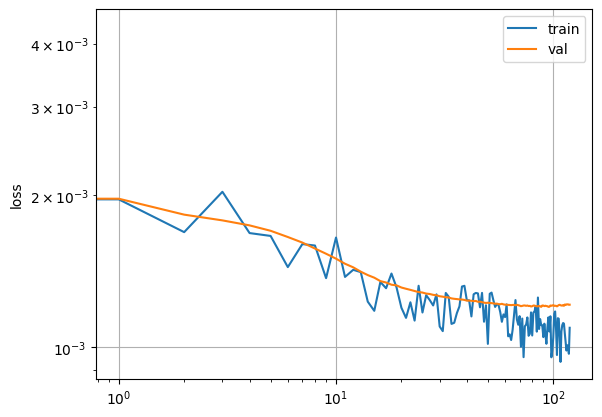

In [123]:
plt.plot(train_loss_history)
plt.plot(val_loss_history)
plt.legend(['train', 'val'])
plt.grid()
plt.yscale('log')
plt.xscale('log')
# plt.xlabel('batches processed')
plt.ylabel('loss')
plt.show()

In [124]:
# validate Ey only
y_pred = model(x_val)
y_pred = extract_amps_from_fields(y_pred, n_propagating).squeeze()
jnp.mean(jnp.abs(y_pred[..., 1] - y_val[..., 1]) ** 2)

Array(0.0011798, dtype=float32)

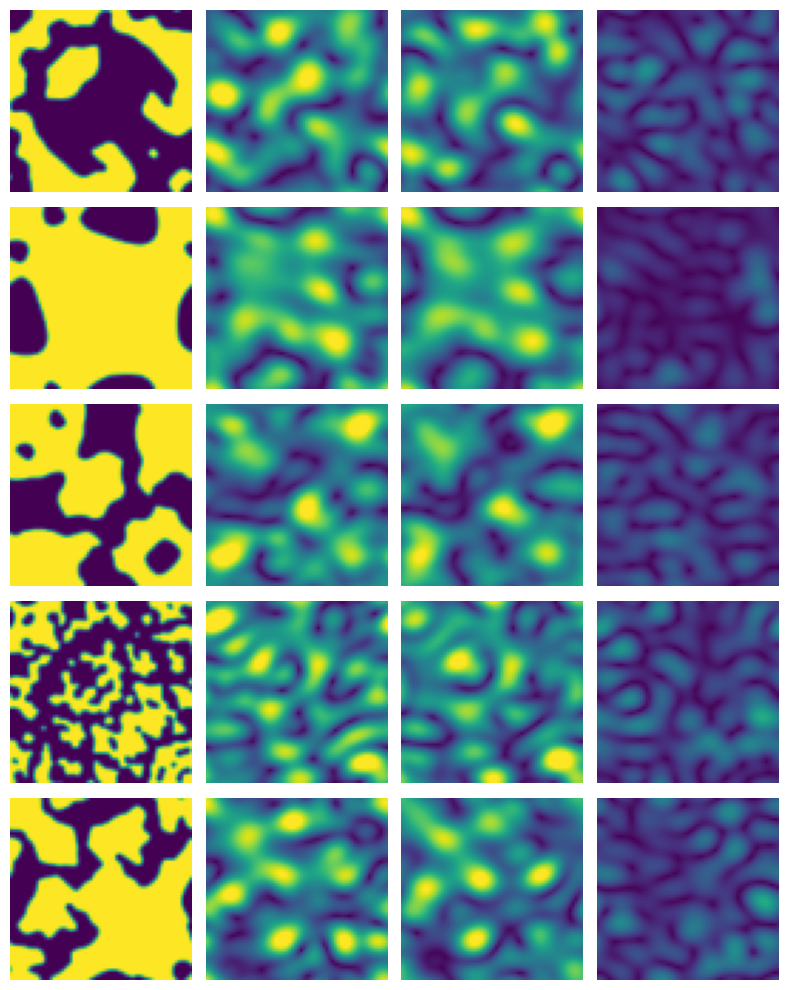

In [125]:
n = 5
starting_i = 0
component_index = 1
fig, ax = plt.subplots(n, 4, figsize=(4*2, n*2))

for i in range(n):
  x = x_val[starting_i + i]
  y = y_val[starting_i + i, :, component_index]
  # x = x_train[starting_i + i]
  # y = y_train[starting_i + i]
  y_pred = model(x[None, ...])
  # y_pred = y_pred[..., component_index]
  y_pred = extract_amps_from_fields(y_pred, n_propagating).squeeze()[..., component_index]


  y_map = np.zeros((64, 64), dtype=complex)
  y_pred_map = np.zeros((64, 64), dtype=complex)
  y_map[propagating_indices[0, :n_propagating], propagating_indices[1, :n_propagating]] = y
  y_pred_map[propagating_indices[0, :n_propagating], propagating_indices[1, :n_propagating]] = y_pred
  y_map = np.fft.fft2(y_map)
  y_pred_map = np.fft.fft2(y_pred_map)

  ax[i, 0].imshow(x, vmin=0, vmax=1)
  # ax[i, 1].imshow(y.real, vmin=-1, vmax=1)
  # ax[i, 2].imshow(y_pred.real, vmin=-1, vmax=1)
  ax[i, 1].imshow(np.abs(y_map), vmin=0, vmax=1.5)
  ax[i, 2].imshow(np.abs(y_pred_map), vmin=0, vmax=1.5)
  ax[i, 3].imshow(np.abs(y_pred_map - y_map), vmin=0, vmax=1.5)

for ax_i in ax.flatten():
  ax_i.set_axis_off()

plt.tight_layout()
plt.show()